In [6]:
# SPATIAL REPRESENTATION OF CHANGES TO SOLUBLE IRON DEPOSITION FLUXES
import xarray as xr
import numpy as np 
from netCDF4 import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, LinearSegmentedColormap, BoundaryNorm
import math
shapefile_path = '/home/hplaas/.local/share/cartopy/shapefiles/natural_earth/physical/ne_110m_coastline.shp'
reader = shpreader.Reader(shapefile_path)

# V1
#sim_directory = "CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38_scale_BF.cam.h1.2009-2011_filtered_MEAN.nc"
sim_directory = "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/\
CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL0.2-WOOD10-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h1.2009-2011_import_DUST_MEDIAN.nc"
MIMI_ds = xr.open_dataset(sim_directory)
MIMI_ds = MIMI_ds.mean(dim="time")

lon = MIMI_ds['lon'].values  # Longitude in degrees
lat = MIMI_ds['lat'].values  # Latitude in degrees

DRY_MIMI = MIMI_ds["FEANSOLDRY"] 
WET_MIMI = MIMI_ds["FEANSOLWET"] 
FEANSOLDEP_MIMI = (DRY_MIMI + WET_MIMI)

# V2
#sim_directory = "CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38_scale_BF.cam.h1.2009-2011_MEAN.nc"
sim_directory = "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/\
CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD10-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h1.2009-2011_import_DUST_MEAN.nc"
v2_ds = xr.open_dataset(sim_directory)
v2_ds = v2_ds.mean(dim="time")

lon = v2_ds['lon'].values  # Longitude in degrees
lat = v2_ds['lat'].values  # Latitude in degrees

DRY_v2 = v2_ds["FEANSOLDRY"] 
WET_v2 = v2_ds["FEANSOLWET"] 
FEANSOLDEP_v2 = (DRY_v2 + WET_v2)

# V3 THIS STILL NEEDS TO BE REPLACED
#sim_directory = "CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38_scale_BF_rerun_v2.cam.h1.2009-2011_MEAN.nc"
sim_directory = "/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/output_files/MEDFEFRAC_reruns/DUST_FIX/\
CAM6-MIMI_2010CLIMO_INDCOAL0.2-RESICOAL33-WOOD56-OIL38-WASTE1.5_MEDFEFRAC_DUSTFETUNED.cam.h1.2009-2011_import_DUST_MEDIAN.nc"
v3_ds = xr.open_dataset(sim_directory)
v3_ds = v3_ds.mean(dim="time")

lon = v3_ds['lon'].values  # Longitude in degrees
lat = v3_ds['lat'].values  # Latitude in degrees

DRY_v3 = v3_ds["FEANSOLDRY"] 
WET_v3 = v3_ds["FEANSOLWET"] 
FEANSOLDEP_v3 = (DRY_v3 + WET_v3)

diff_1 = FEANSOLDEP_v2 / FEANSOLDEP_MIMI 
diff_2 = FEANSOLDEP_v3 / FEANSOLDEP_v2 

print("done")

print(np.min(diff_1))
print(np.max(diff_1))
print(np.min(diff_2))
print(np.max(diff_2))

ValueError: Dataset does not contain the dimensions: ['time']

In [2]:
# making a mask of places where factor increase by 2 or more for both types 
diff_3 = FEANSOLDEP_v3 / FEANSOLDEP_MIMI
RESI_influence_mask = (diff_3 >= 2.0).astype(int)

print(RESI_influence_mask) 

# Create a figure and axis
#fig = plt.figure(figsize=(10, 8), edgecolor='w')
#ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
#ax.set_global()

RESI_influence_mask.name = "RESI_INF"
RESI_influence_mask = RESI_influence_mask.to_dataset()
RESI_influence_mask.to_netcdf("RESI_influence_mask_MEDFRAC.nc")

# Set the background color and add coastlines
#ax.set_facecolor('white')
#ax.coastlines(resolution='110m', color='black')
#ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5)
#c = ax.pcolormesh(lon, lat, RESI_influence_mask.values, transform=ccrs.PlateCarree())
#plt.show()

<xarray.DataArray (lat: 192, lon: 288)> Size: 442kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8


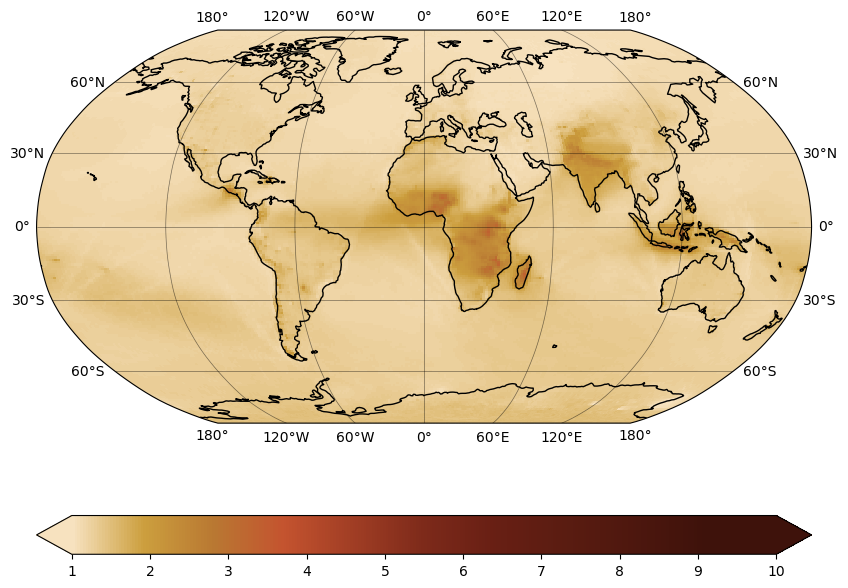

In [5]:
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, LinearSegmentedColormap, BoundaryNorm

color0 = '#fdf3e6'  # Very light warm beige
color1 = '#f7e2bf'  # Light warm beige
color2 = '#cc9f3e'  # Warm mustard
color3 = '#b97832'  # Deep golden brown
color4 = '#c4532f'  # Burnt orange-red
color5 = '#a03d24'  # Earthy brick red
color6 = '#7d2a1a'  # Deep rust red
color7 = '#681f14'  # Dark rust red
color8 = '#5a1c11'  # Dark red-brown
color9 = '#4d170e'  # Very dark reddish-brown
color10 = '#3e120b'  # Near-black warm brown
color11 = '#2e0d08'  # Deep blackened red
color12 = 'black'  # Deep blackened red

#positions = [i/10 for i in range(11)]
positions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
colors = [color1, color2, color3, color4, color5, color6, color7, color8, color9, color10, color10]
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))

vmin = 1
vmax = 10

# Create a figure and axis
boundaries = np.linspace(vmin, vmax, num=len(colors))
# Use continuous normalization for smoother plot
norm = Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(10, 8), edgecolor='w')
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor('white')
ax.coastlines(resolution='110m', color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5)

# Plot with continuous colormap
c = ax.pcolormesh(lon, lat, diff_2.values, cmap=custom_cmap, norm=norm, transform=ccrs.PlateCarree())
cbar = plt.colorbar(c, orientation='horizontal', extend='both')
plt.savefig('/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/regressions/BIOF-RESI-deposition_waste_import_dust.png')
plt.show()

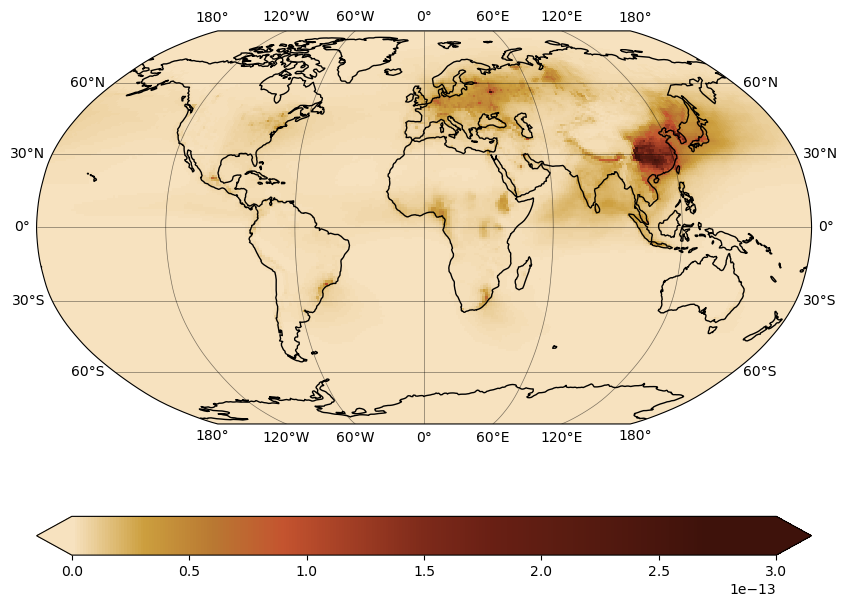

In [8]:
# PLOTTING FLUXES THEMSELVES

from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, LinearSegmentedColormap, BoundaryNorm

color0 = '#fdf3e6'  # Very light warm beige
color1 = '#f7e2bf'  # Light warm beige
color2 = '#cc9f3e'  # Warm mustard
color3 = '#b97832'  # Deep golden brown
color4 = '#c4532f'  # Burnt orange-red
color5 = '#a03d24'  # Earthy brick red
color6 = '#7d2a1a'  # Deep rust red
color7 = '#681f14'  # Dark rust red
color8 = '#5a1c11'  # Dark red-brown
color9 = '#4d170e'  # Very dark reddish-brown
color10 = '#3e120b'  # Near-black warm brown
color11 = '#2e0d08'  # Deep blackened red
color12 = 'black'  # Deep blackened red

#positions = [i/10 for i in range(11)]
positions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
colors = [color1, color2, color3, color4, color5, color6, color7, color8, color9, color10, color10]
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))

vmin = 0
vmax = 3E-13

# Create a figure and axis
boundaries = np.linspace(vmin, vmax, num=len(colors))
# Use continuous normalization for smoother plot
norm = Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(10, 8), edgecolor='w')
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor('white')
ax.coastlines(resolution='110m', color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5)

# Plot with continuous colormap
# other option FEANSOLDEP_v3, FEANSOLDEP_MIMI
c = ax.pcolormesh(lon, lat, FEANSOLDEP_MIMI.values, cmap=custom_cmap, norm=norm, transform=ccrs.PlateCarree())
cbar = plt.colorbar(c, orientation='horizontal', extend='both')
plt.savefig('/home/hplaas/nobackup/JupyterLinks/notebooks/cesm_files/Plots/soil_state_validation/BASE-for-soilstate_flux_MEDIAN.png')
plt.show()